# Backtest: Umbrales Fijos vs Auto-Calibrados

Simula cómo habría funcionado la ventana rolling de P75/P25 sobre el dataset real,
comparando con los umbrales fijos del backtest original.

### Lo que probamos
- **Fijo**: umbrales P75/P25 calculados una vez sobre el train set
- **Rolling-500**: P75/P25 sobre los últimos 500 snapshots
- **Rolling-1000**: P75/P25 sobre los últimos 1000 snapshots
- **Rolling-200**: P75/P25 sobre los últimos 200 snapshots (más reactivo)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# ═══════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═══════════════════════════════════════════════════════════════════════
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    STAKE        = 10.0,
    INIT_CAPITAL = 100.0,
    ENTRY_LO     = 0.10,
    ENTRY_HI     = 0.60,
    TRAIN_FRAC   = 0.40,
    VAL_FRAC     = 0.15,
    PERCENTILE   = 75,
)

# Ventanas rolling a probar
ROLLING_WINDOWS = [200, 500, 1000]

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<16} = {v}")
print(f"  Ventanas rolling: {ROLLING_WINDOWS}")

Configuración:
  DATA_PATH        = ../dataset_with_resolution.csv
  STAKE            = 10.0
  INIT_CAPITAL     = 100.0
  ENTRY_LO         = 0.1
  ENTRY_HI         = 0.6
  TRAIN_FRAC       = 0.4
  VAL_FRAC         = 0.15
  PERCENTILE       = 75
  Ventanas rolling: [200, 500, 1000]


---
## 1 · Carga y Preparación

In [2]:
# ═══ Carga ════════════════════════════════════════════════════════════
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])
if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')
df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

# Limpiar
res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)
df['y'] = (df['resolution'].str.lower() == 'up').astype(int)

print(f"Dataset: {len(df):,} filas, {df['market_slug'].nunique()} mercados")

# ═══ Split ════════════════════════════════════════════════════════════
market_order = df.groupby('market_slug')['timestamp'].min().sort_values().index.tolist()
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
test_m  = market_order[n_train + n_val:]

tr = df[df['market_slug'].isin(train_m)].copy()
te = df[df['market_slug'].isin(test_m)].copy()

# Umbral fijo del train
tr_w = tr[(tr['market_progress'] >= CFG['ENTRY_LO']) & (tr['market_progress'] <= CFG['ENTRY_HI'])]
FIXED_UP   = tr_w['btc_return_since_open'].quantile(CFG['PERCENTILE'] / 100)
FIXED_DOWN = tr_w['btc_return_since_open'].quantile(1 - CFG['PERCENTILE'] / 100)

print(f"\nTrain: {len(train_m)} mercados | Test: {len(test_m)} mercados")
print(f"Umbrales FIJOS (del train): UP={FIXED_UP:+.6f}  DOWN={FIXED_DOWN:+.6f}")

Dataset: 142,717 filas, 1485 mercados

Train: 594 mercados | Test: 669 mercados
Umbrales FIJOS (del train): UP=+0.000334  DOWN=-0.000391


---
## 2 · Simulación Cronológica con Rolling Calibrator

Recorremos los mercados de test en orden cronológico.
Para cada mercado, el calibrador rolling ya tiene los datos de todos los
snapshots anteriores (como pasaría en producción).

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# 2. SIMULACIÓN CRONOLÓGICA
# ═══════════════════════════════════════════════════════════════════════

class RollingCalibrator:
    """Réplica exacta del ThresholdCalibrator del signal_engine."""
    def __init__(self, window_size, percentile, seed_up, seed_down):
        self.buffer = deque(maxlen=window_size)
        self.percentile = percentile
        self.threshold_up = seed_up
        self.threshold_down = seed_down
        self.window_size = window_size
        self.min_samples = 50

    def feed(self, values):
        """Alimentar con array de btc_return_since_open."""
        for v in values:
            if not np.isnan(v):
                self.buffer.append(v)
        if len(self.buffer) >= self.min_samples:
            arr = np.array(self.buffer)
            self.threshold_up = float(np.percentile(arr, self.percentile))
            self.threshold_down = float(np.percentile(arr, 100 - self.percentile))

    @property
    def is_calibrated(self):
        return len(self.buffer) >= self.min_samples


def run_backtest(test_df, cfg, fixed_up, fixed_down, rolling_window=None, percentile=75):
    """
    Backtest cronológico. Si rolling_window=None → umbrales fijos.
    Si rolling_window=int → calibrador rolling que se alimenta mercado a mercado.
    """
    STAKE = cfg['STAKE']
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']

    # Preparar calibrador
    if rolling_window is not None:
        cal = RollingCalibrator(rolling_window, percentile, fixed_up, fixed_down)
        # Pre-cargar con datos de train (como hace el signal_engine en producción)
        train_vals = tr_w['btc_return_since_open'].dropna().values
        # Usar solo la cola para no desbordar la ventana
        seed = train_vals[-rolling_window * 3:] if len(train_vals) > rolling_window * 3 else train_vals
        cal.feed(seed)
    else:
        cal = None

    # Procesar mercados en orden cronológico
    market_order_test = (
        test_df.groupby('market_slug')['timestamp'].min()
        .sort_values().index.tolist()
    )

    trades = []
    threshold_history = []  # para graficar evolución

    for mkt in market_order_test:
        snaps = test_df[test_df['market_slug'] == mkt].sort_values('timestamp')
        window = snaps[(snaps['market_progress'] >= lo) & (snaps['market_progress'] <= hi)]

        if window.empty:
            # Aún sin trade, alimentar calibrador con los snapshots de este mercado
            if cal is not None:
                op_snaps = snaps[(snaps['market_progress'] >= lo) & (snaps['market_progress'] <= hi)]
                cal.feed(op_snaps['btc_return_since_open'].values)
            continue

        # Umbrales actuales
        if cal is not None:
            t_up = cal.threshold_up
            t_down = cal.threshold_down
        else:
            t_up = fixed_up
            t_down = fixed_down

        # Buscar primer snapshot con señal
        entry_row = None
        direction = None
        for _, row in window.iterrows():
            ret = row.get('btc_return_since_open', np.nan)
            if pd.isna(ret):
                continue
            if ret > t_up:
                ask = row.get('up_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row
                    direction = 'UP'
                    break
            elif ret < t_down:
                ask = row.get('down_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row
                    direction = 'DOWN'
                    break

        # Registrar umbral para el historial (incluso si no hay trade)
        ts_mkt = snaps['timestamp'].iloc[0]
        threshold_history.append({
            'timestamp': ts_mkt,
            'threshold_up': t_up,
            'threshold_down': t_down,
            'traded': entry_row is not None,
        })

        # Alimentar calibrador con snapshots de este mercado (DESPUÉS de decidir)
        if cal is not None:
            op_snaps = snaps[(snaps['market_progress'] >= lo) & (snaps['market_progress'] <= hi)]
            cal.feed(op_snaps['btc_return_since_open'].values)

        if entry_row is None:
            continue

        # PnL
        entry_ask = entry_row['up_ask_p_1'] if direction == 'UP' else entry_row['down_ask_p_1']
        resolution = snaps['resolution'].iloc[0]
        actual_up = (resolution.lower() == 'up')
        won = (actual_up if direction == 'UP' else not actual_up)
        win_net = entry_row['up_win_net'] if direction == 'UP' else entry_row['down_win_net']
        loss_net = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl = win_net if won else loss_net

        trades.append({
            'timestamp': entry_row['timestamp'],
            'market': mkt,
            'direction': direction,
            'won': won,
            'entry_ask': entry_ask,
            'entry_progress': entry_row['market_progress'],
            'btc_return': entry_row['btc_return_since_open'],
            'threshold_up': t_up,
            'threshold_down': t_down,
            'pnl': pnl,
        })

    # Montar resultados
    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float), pd.DataFrame(threshold_history)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity'] = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])

    return tdf, equity_s, pd.DataFrame(threshold_history)


print("Motor de backtest cronológico definido.")

Motor de backtest cronológico definido.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# 2b. EJECUTAR BACKTESTS
# ═══════════════════════════════════════════════════════════════════════
pct = CFG['PERCENTILE']

# Variante fija
configs = [('Fijo (train P75/P25)', None)]
for w in ROLLING_WINDOWS:
    configs.append((f'Rolling-{w}', w))

all_results = {}
all_logs = {}
all_equity = {}
all_thresholds = {}

print(f"Ejecutando {len(configs)} variantes sobre {len(test_m)} mercados de test...\n")
print(f"{'Variante':<26} {'N':>5} {'WR':>7} {'PnL(€)':>10} {'ROI':>8} {'Sharpe':>8} {'MDD':>8}")
print("═" * 80)

for name, window in configs:
    tdf, eq_s, th_hist = run_backtest(te, CFG, FIXED_UP, FIXED_DOWN,
                                       rolling_window=window, percentile=pct)
    all_logs[name] = tdf
    all_equity[name] = eq_s
    all_thresholds[name] = th_hist

    if tdf.empty:
        print(f"{name:<26} {'sin trades':>5}")
        all_results[name] = dict(n=0, wr=np.nan, pnl=0, roi=0, sharpe=0, mdd=0)
        continue

    n = len(tdf)
    wr = tdf['won'].mean()
    pnl = tdf['pnl'].sum()
    roi = pnl / CFG['INIT_CAPITAL']
    pa = tdf['pnl'].values
    sharpe = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)
    eq = eq_s.values
    rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()

    all_results[name] = dict(n=n, wr=wr, pnl=pnl, roi=roi, sharpe=sharpe, mdd=mdd)

    print(f"{name:<26} {n:>5} {wr:>6.1%} {pnl:>+10.2f} {roi:>+7.2%} "
          f"{sharpe:>8.3f} {mdd:>+7.2%}")

print("═" * 80)

Ejecutando 4 variantes sobre 669 mercados de test...

Variante                       N      WR     PnL(€)      ROI   Sharpe      MDD
════════════════════════════════════════════════════════════════════════════════
Fijo (train P75/P25)         638  67.9%     +97.25 +97.25%    0.535 -80.35%
Rolling-200                  625  66.1%      +6.44  +6.44%    0.035 -116.01%
Rolling-500                  616  69.3%    +119.29 +119.29%    0.687 -53.88%
Rolling-1000                 614  69.7%    +120.73 +120.73%    0.702 -55.67%
════════════════════════════════════════════════════════════════════════════════


---
## 3 · Evolución de los Umbrales

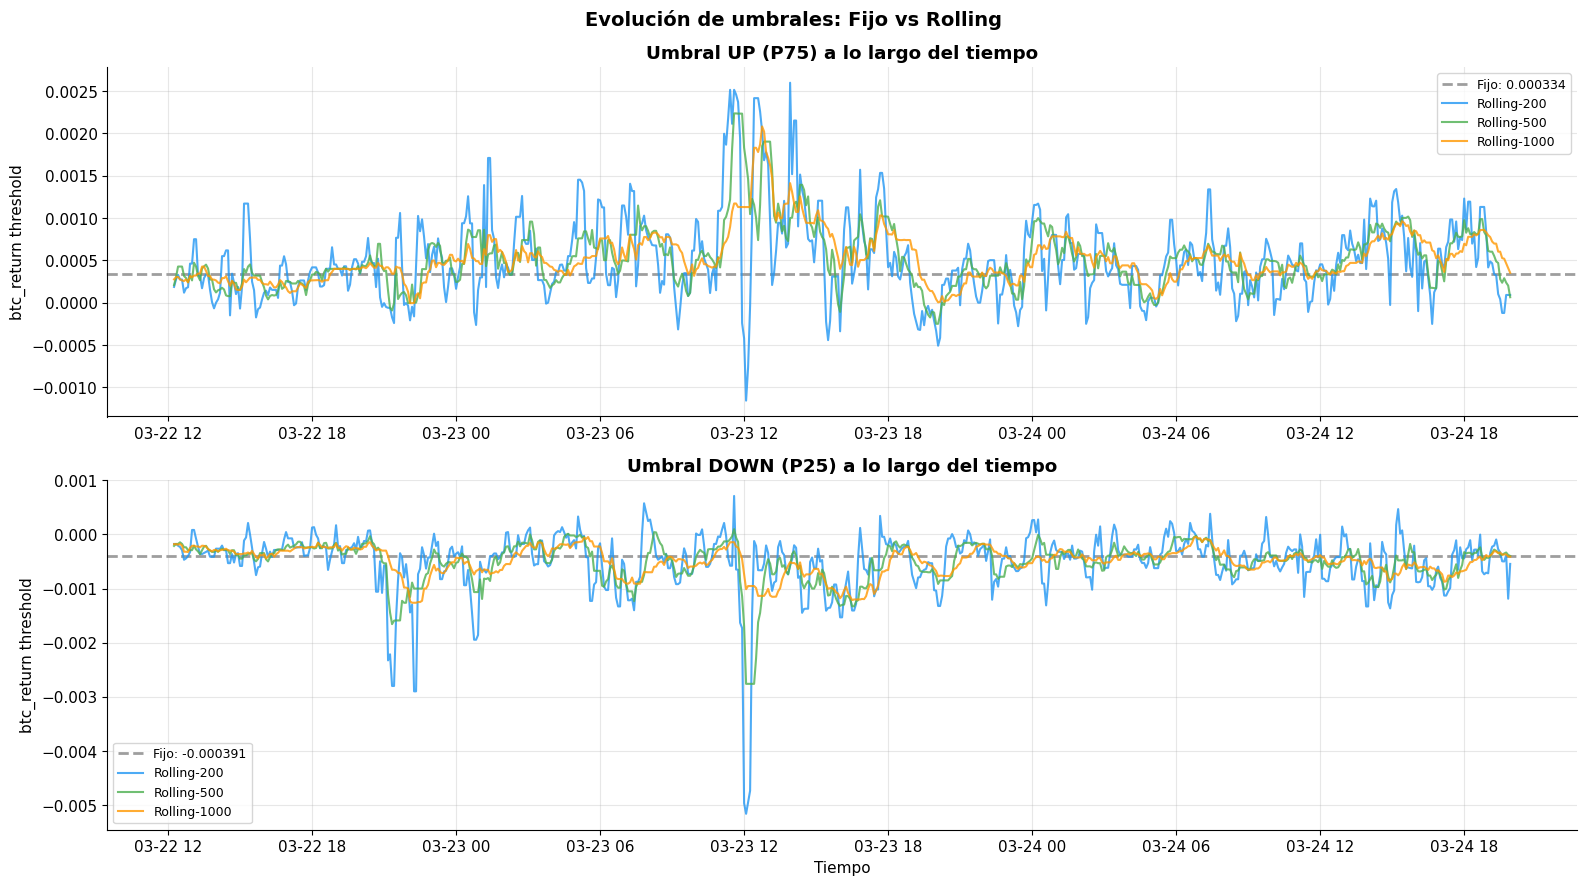

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# 3. EVOLUCIÓN TEMPORAL DE LOS UMBRALES
# ═══════════════════════════════════════════════════════════════════════
colors = {'Fijo (train P75/P25)': '#9E9E9E'}
palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, w in enumerate(ROLLING_WINDOWS):
    colors[f'Rolling-{w}'] = palette[i]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Panel 1: Umbral UP
ax = axes[0]
ax.axhline(FIXED_UP, ls='--', color='#9E9E9E', lw=2, label=f'Fijo: {FIXED_UP:.6f}')
for w in ROLLING_WINDOWS:
    name = f'Rolling-{w}'
    th = all_thresholds[name]
    if not th.empty:
        ax.plot(th['timestamp'], th['threshold_up'],
                label=name, color=colors[name], lw=1.5, alpha=0.8)
ax.set_title('Umbral UP (P75) a lo largo del tiempo', fontweight='bold')
ax.set_ylabel('btc_return threshold')
ax.legend(fontsize=9)

# Panel 2: Umbral DOWN
ax = axes[1]
ax.axhline(FIXED_DOWN, ls='--', color='#9E9E9E', lw=2, label=f'Fijo: {FIXED_DOWN:.6f}')
for w in ROLLING_WINDOWS:
    name = f'Rolling-{w}'
    th = all_thresholds[name]
    if not th.empty:
        ax.plot(th['timestamp'], th['threshold_down'],
                label=name, color=colors[name], lw=1.5, alpha=0.8)
ax.set_title('Umbral DOWN (P25) a lo largo del tiempo', fontweight='bold')
ax.set_ylabel('btc_return threshold')
ax.set_xlabel('Tiempo')
ax.legend(fontsize=9)

plt.suptitle('Evolución de umbrales: Fijo vs Rolling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 · Curvas de Equity Comparadas

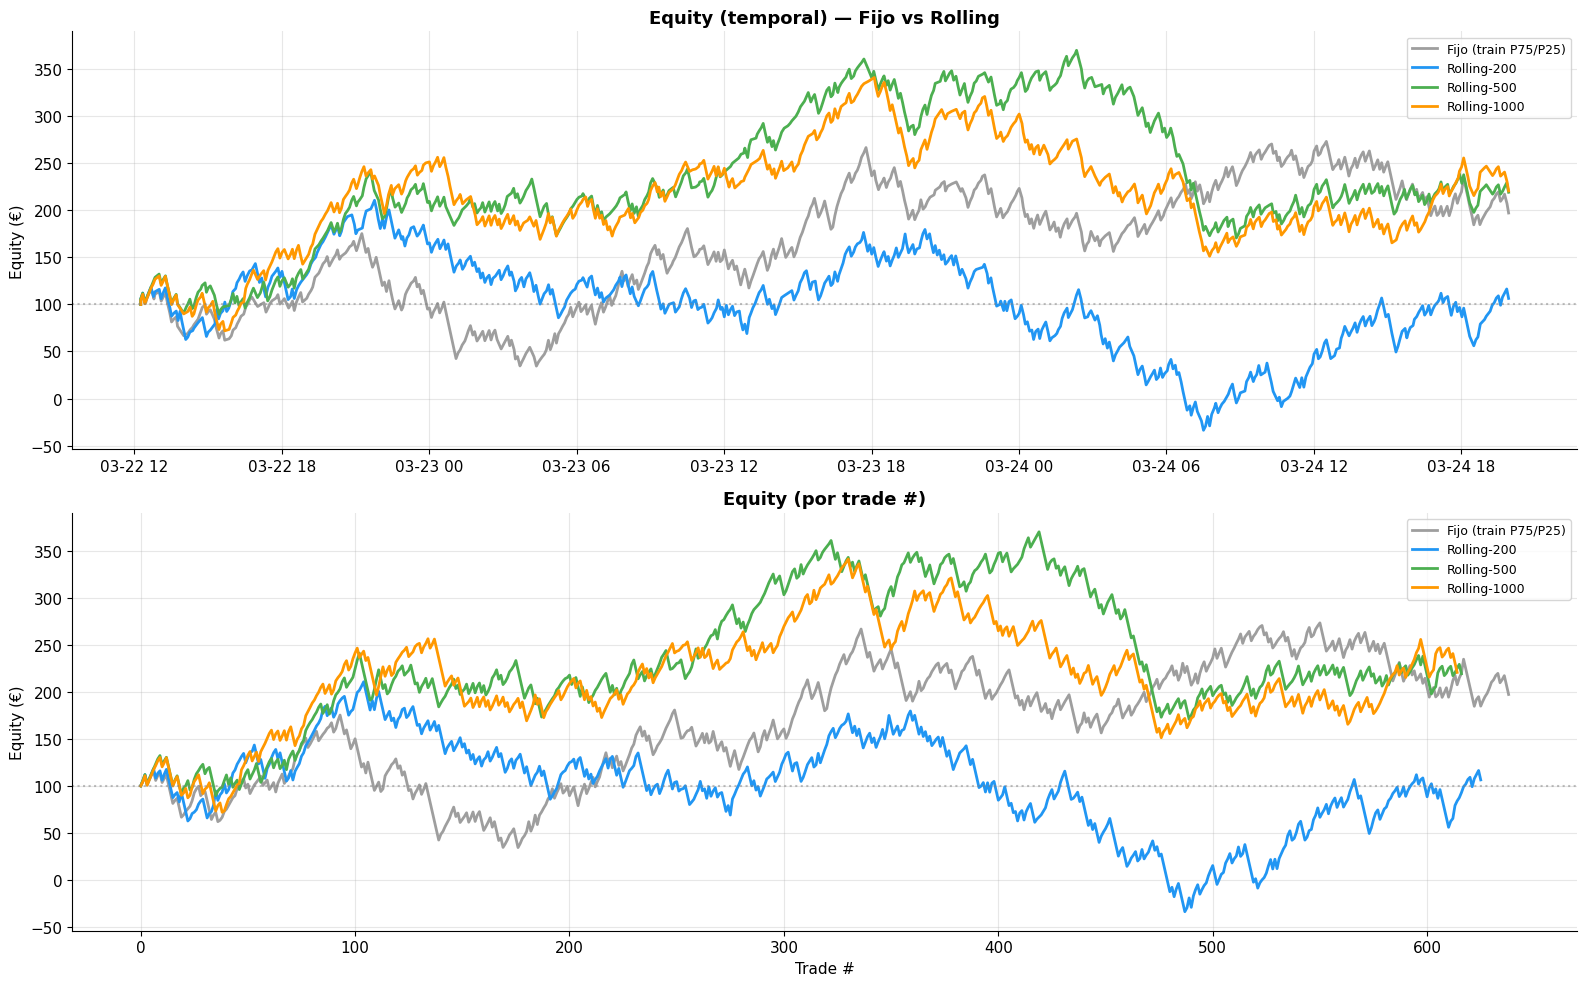

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 4. CURVAS DE EQUITY
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel 1: Temporal
ax = axes[0]
for name in all_equity:
    eq = all_equity[name]
    if len(eq) > 1:
        ax.plot(eq.index, eq.values, label=name, color=colors[name], lw=2)
ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', alpha=0.5)
ax.set_title('Equity (temporal) — Fijo vs Rolling', fontweight='bold', fontsize=13)
ax.set_ylabel('Equity (€)')
ax.legend(fontsize=9)

# Panel 2: Por trade #
ax = axes[1]
for name in all_equity:
    eq = all_equity[name]
    if len(eq) > 1:
        ax.plot(range(len(eq)), eq.values, label=name, color=colors[name], lw=2)
ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', alpha=0.5)
ax.set_title('Equity (por trade #)', fontweight='bold', fontsize=13)
ax.set_ylabel('Equity (€)')
ax.set_xlabel('Trade #')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5 · Comparativa Detallada

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# 5. TABLA COMPARATIVA
# ═══════════════════════════════════════════════════════════════════════
comp = pd.DataFrame(all_results).T
comp = comp.sort_values('roi', ascending=False)

print("COMPARATIVA DETALLADA")
print("═" * 90)
print(f"{'Variante':<26} {'N':>5} {'WR':>7} {'PnL(€)':>10} {'ROI':>8} "
      f"{'ROI/trade':>10} {'Sharpe':>8} {'MDD':>8}")
print("─" * 90)

for name, row in comp.iterrows():
    n = int(row['n'])
    if n == 0:
        print(f"{name:<26} sin trades")
        continue
    roi_t = row['pnl'] / (n * CFG['STAKE']) if n > 0 else 0
    wr_s = f"{row['wr']:.1%}"
    print(f"{name:<26} {n:>5} {wr_s:>7} {row['pnl']:>+10.2f} {row['roi']:>+7.2%} "
          f"{roi_t:>+9.2%} {row['sharpe']:>8.3f} {row['mdd']:>+7.2%}")

print("═" * 90)

# Mejor variante
best = comp.index[0]
print(f"\nMejor por ROI: {best} ({comp.loc[best, 'roi']:+.2%})")

# ¿Cuál tiene más trades?
most_trades = comp['n'].idxmax()
print(f"Más trades: {most_trades} (N={int(comp.loc[most_trades, 'n'])})")

# ¿Fijo vs Rolling?
fixed_name = 'Fijo (train P75/P25)'
if fixed_name in comp.index:
    fixed_roi = comp.loc[fixed_name, 'roi']
    for name, row in comp.iterrows():
        if name != fixed_name and row['n'] > 0:
            diff = row['roi'] - fixed_roi
            print(f"  {name} vs Fijo: ΔROI = {diff:+.2%}")

COMPARATIVA DETALLADA
══════════════════════════════════════════════════════════════════════════════════════════
Variante                       N      WR     PnL(€)      ROI  ROI/trade   Sharpe      MDD
──────────────────────────────────────────────────────────────────────────────────────────
Rolling-1000                 614   69.7%    +120.73 +120.73%    +1.97%    0.702 -55.67%
Rolling-500                  616   69.3%    +119.29 +119.29%    +1.94%    0.687 -53.88%
Fijo (train P75/P25)         638   67.9%     +97.25 +97.25%    +1.52%    0.535 -80.35%
Rolling-200                  625   66.1%      +6.44  +6.44%    +0.10%    0.035 -116.01%
══════════════════════════════════════════════════════════════════════════════════════════

Mejor por ROI: Rolling-1000 (+120.73%)
Más trades: Fijo (train P75/P25) (N=638)
  Rolling-1000 vs Fijo: ΔROI = +23.48%
  Rolling-500 vs Fijo: ΔROI = +22.05%
  Rolling-200 vs Fijo: ΔROI = -90.81%


---
## 6 · Análisis de Cuándo Divergen los Umbrales

¿En qué momentos los umbrales rolling se alejan más del fijo?
¿Coincide con cambios de régimen de BTC?

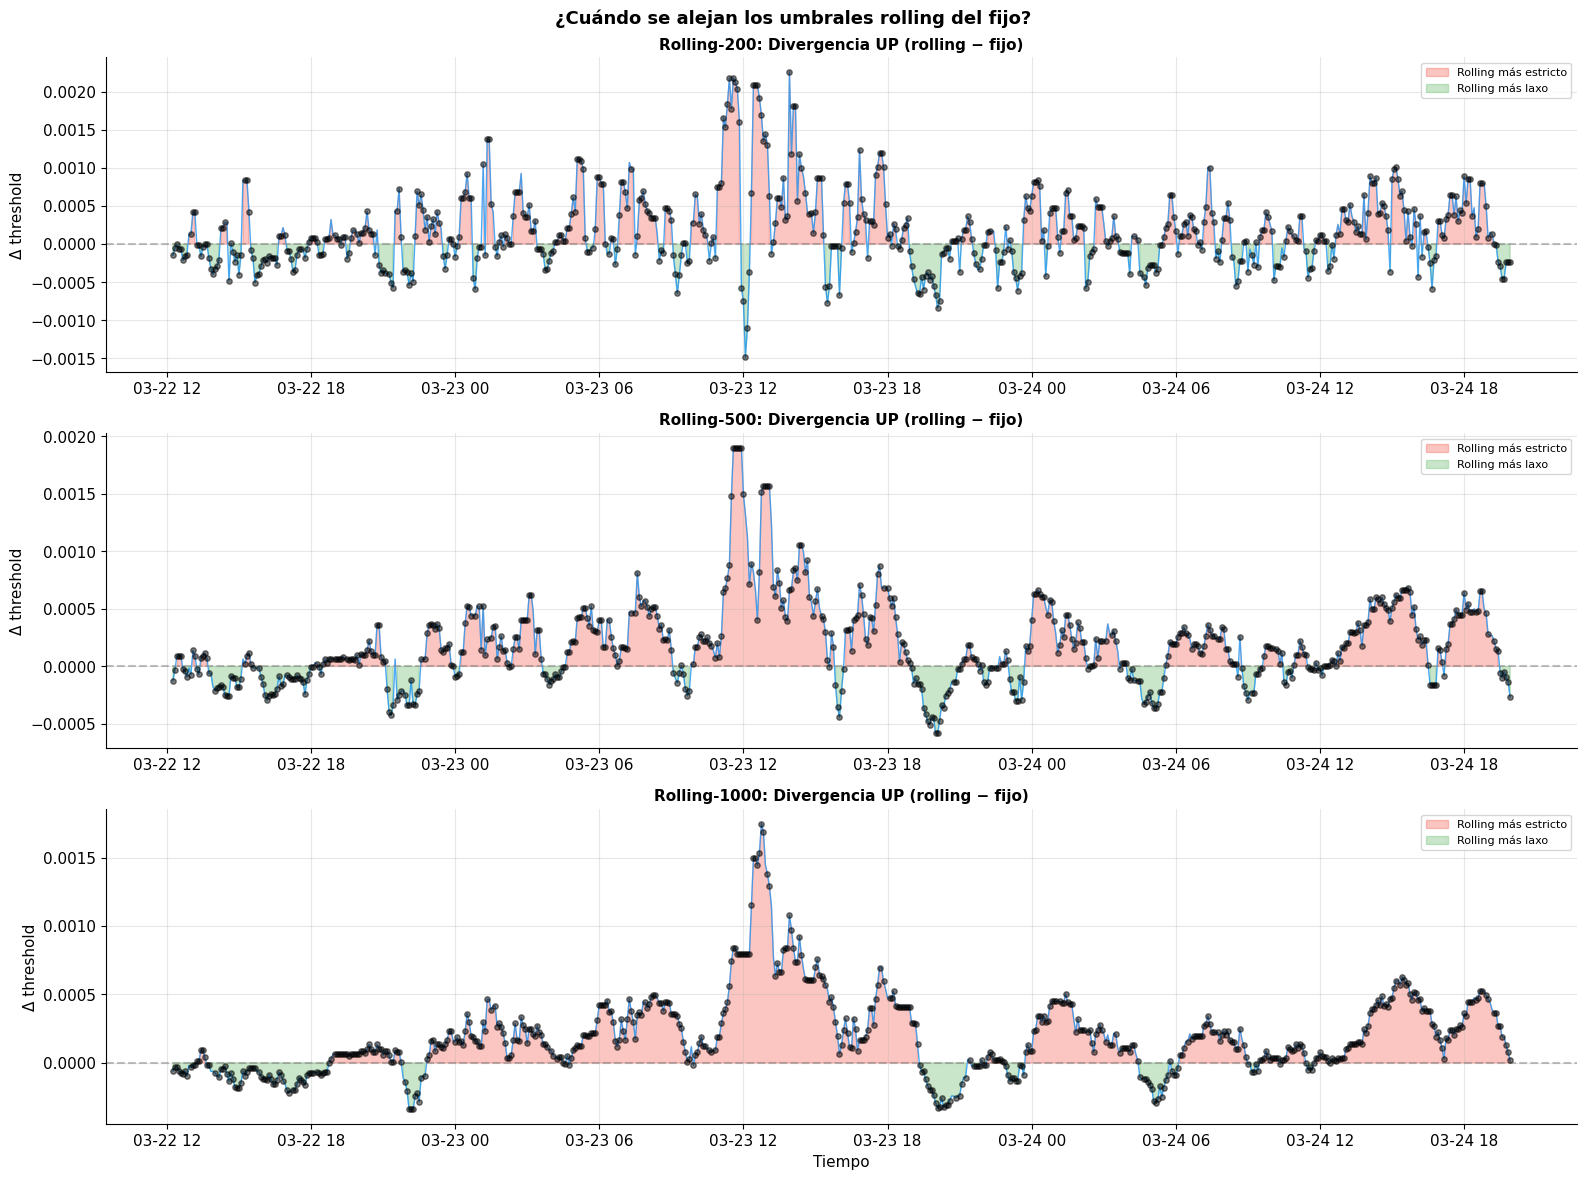

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# 6. DIVERGENCIA ROLLING vs FIJO
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(len(ROLLING_WINDOWS), 1,
                          figsize=(16, 4 * len(ROLLING_WINDOWS)))
if len(ROLLING_WINDOWS) == 1:
    axes = [axes]

for i, w in enumerate(ROLLING_WINDOWS):
    ax = axes[i]
    name = f'Rolling-{w}'
    th = all_thresholds[name]
    if th.empty:
        continue

    # Divergencia = umbral rolling - umbral fijo
    div_up = th['threshold_up'] - FIXED_UP
    div_dn = th['threshold_down'] - FIXED_DOWN

    ax.fill_between(th['timestamp'], div_up, 0, where=div_up > 0,
                    alpha=0.3, color='#F44336', label='Rolling más estricto')
    ax.fill_between(th['timestamp'], div_up, 0, where=div_up <= 0,
                    alpha=0.3, color='#4CAF50', label='Rolling más laxo')
    ax.plot(th['timestamp'], div_up, color='#2196F3', lw=1, alpha=0.8)
    ax.axhline(0, ls='--', color='gray', alpha=0.5)

    # Marcar trades
    traded = th[th['traded']]
    if not traded.empty:
        y_trade = (traded['threshold_up'] - FIXED_UP).values
        ax.scatter(traded['timestamp'], y_trade,
                   color='black', s=15, zorder=5, alpha=0.5)

    ax.set_title(f'{name}: Divergencia UP (rolling − fijo)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Δ threshold')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Tiempo')
plt.suptitle('¿Cuándo se alejan los umbrales rolling del fijo?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Trades Diferentes entre Fijo y Rolling

¿Cuántos trades son iguales y cuántos son distintos?

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 7. OVERLAP DE TRADES
# ═══════════════════════════════════════════════════════════════════════
fixed_name = 'Fijo (train P75/P25)'
fixed_log = all_logs.get(fixed_name, pd.DataFrame())

if not fixed_log.empty:
    fixed_mkts = set(fixed_log['market'])

    print("OVERLAP DE TRADES: ¿Cuántos mercados comparten fijo y rolling?")
    print("═" * 70)

    for w in ROLLING_WINDOWS:
        name = f'Rolling-{w}'
        rlog = all_logs.get(name, pd.DataFrame())
        if rlog.empty:
            continue
        roll_mkts = set(rlog['market'])

        shared = fixed_mkts & roll_mkts
        only_fixed = fixed_mkts - roll_mkts
        only_roll  = roll_mkts - fixed_mkts

        print(f"\n  {name} vs Fijo:")
        print(f"    Mercados en ambos:       {len(shared)}")
        print(f"    Solo en Fijo:            {len(only_fixed)}")
        print(f"    Solo en {name}:  {len(only_roll)}")

        # De los compartidos, ¿misma dirección?
        if shared:
            fixed_dirs = fixed_log.set_index('market')['direction']
            roll_dirs  = rlog.set_index('market')['direction']
            same_dir = sum(1 for m in shared if fixed_dirs[m] == roll_dirs[m])
            print(f"    Misma dirección:         {same_dir}/{len(shared)} ({same_dir/len(shared):.0%})")

        # PnL de los trades exclusivos del rolling
        if only_roll:
            excl = rlog[rlog['market'].isin(only_roll)]
            print(f"    PnL trades exclusivos:   {excl['pnl'].sum():+.2f}€ "
                  f"(WR={excl['won'].mean():.1%}, N={len(excl)})")

        # PnL de los trades que el fijo tiene pero el rolling no
        if only_fixed:
            excl_f = fixed_log[fixed_log['market'].isin(only_fixed)]
            print(f"    PnL trades perdidos:     {excl_f['pnl'].sum():+.2f}€ "
                  f"(WR={excl_f['won'].mean():.1%}, N={len(excl_f)})")

OVERLAP DE TRADES: ¿Cuántos mercados comparten fijo y rolling?
══════════════════════════════════════════════════════════════════════

  Rolling-200 vs Fijo:
    Mercados en ambos:       605
    Solo en Fijo:            33
    Solo en Rolling-200:  20
    Misma dirección:         505/605 (83%)
    PnL trades exclusivos:   -85.41€ (WR=35.0%, N=20)
    PnL trades perdidos:     +45.87€ (WR=75.8%, N=33)

  Rolling-500 vs Fijo:
    Mercados en ambos:       600
    Solo en Fijo:            38
    Solo en Rolling-500:  16
    Misma dirección:         530/600 (88%)
    PnL trades exclusivos:   +36.78€ (WR=75.0%, N=16)
    PnL trades perdidos:     -47.29€ (WR=57.9%, N=38)

  Rolling-1000 vs Fijo:
    Mercados en ambos:       603
    Solo en Fijo:            35
    Solo en Rolling-1000:  11
    Misma dirección:         540/603 (90%)
    PnL trades exclusivos:   +49.50€ (WR=90.9%, N=11)
    PnL trades perdidos:     +45.96€ (WR=74.3%, N=35)


---
## 8 · Veredicto

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# 8. VEREDICTO
# ═══════════════════════════════════════════════════════════════════════
D = '═' * 70
print(D)
print('  VEREDICTO: UMBRALES FIJOS vs AUTO-CALIBRADOS')
print(D)

comp_sorted = comp.sort_values('roi', ascending=False)

print(f"\n  Ranking por ROI:")
for rank, (name, row) in enumerate(comp_sorted.iterrows(), 1):
    if row['n'] == 0:
        continue
    print(f"    {rank}. {name:<26} ROI={row['roi']:+.2%}  PnL={row['pnl']:+.2f}€  "
          f"N={int(row['n'])}  Sharpe={row['sharpe']:.2f}")

# Comparar rolling vs fijo
fixed_roi = comp.loc[fixed_name, 'roi'] if fixed_name in comp.index else 0
rolling_rois = {name: row['roi'] for name, row in comp.iterrows()
                if name != fixed_name and row['n'] > 0}

if rolling_rois:
    best_rolling = max(rolling_rois, key=rolling_rois.get)
    best_rolling_roi = rolling_rois[best_rolling]
    delta = best_rolling_roi - fixed_roi

    print(f"\n  Mejor rolling: {best_rolling} (ROI={best_rolling_roi:+.2%})")
    print(f"  vs Fijo:       ROI={fixed_roi:+.2%}")
    print(f"  Diferencia:    {delta:+.2%}")

    if delta > 0.005:  # >0.5% mejor
        print(f"\n  ✅ Auto-calibración MEJORA el resultado → usar {best_rolling}")
    elif delta > -0.005:  # similar
        print(f"\n  ≈ Resultados similares — auto-calibración no perjudica")
        print(f"    → Recomendable activarla como seguro ante cambios de régimen")
    else:
        print(f"\n  ⚠️ Auto-calibración EMPEORA en este periodo")
        print(f"    → Podría ser que el dataset es demasiado corto (~4 días)")
        print(f"    → Considerar: --no-autocalibrate en producción")
        print(f"    → O usar ventana más larga para suavizar")

print(f"\n  ℹ️  Nota: con solo ~4 días de datos, la diferencia puede no ser")
print(f"      estadísticamente significativa. La auto-calibración brilla")
print(f"      cuando BTC cambia de régimen (alta↔baja vol), lo cual")
print(f"      requiere semanas de datos para observar.")
print(D)

══════════════════════════════════════════════════════════════════════
  VEREDICTO: UMBRALES FIJOS vs AUTO-CALIBRADOS
══════════════════════════════════════════════════════════════════════

  Ranking por ROI:
    1. Rolling-1000               ROI=+120.73%  PnL=+120.73€  N=614  Sharpe=0.70
    2. Rolling-500                ROI=+119.29%  PnL=+119.29€  N=616  Sharpe=0.69
    3. Fijo (train P75/P25)       ROI=+97.25%  PnL=+97.25€  N=638  Sharpe=0.54
    4. Rolling-200                ROI=+6.44%  PnL=+6.44€  N=625  Sharpe=0.03

  Mejor rolling: Rolling-1000 (ROI=+120.73%)
  vs Fijo:       ROI=+97.25%
  Diferencia:    +23.48%

  ✅ Auto-calibración MEJORA el resultado → usar Rolling-1000

  ℹ️  Nota: con solo ~4 días de datos, la diferencia puede no ser
      estadísticamente significativa. La auto-calibración brilla
      cuando BTC cambia de régimen (alta↔baja vol), lo cual
      requiere semanas de datos para observar.
══════════════════════════════════════════════════════════════════════
